In [1]:
# [머신러닝 모델 평가 지표 학습을 위한 필수 라이브러리 로드]
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics

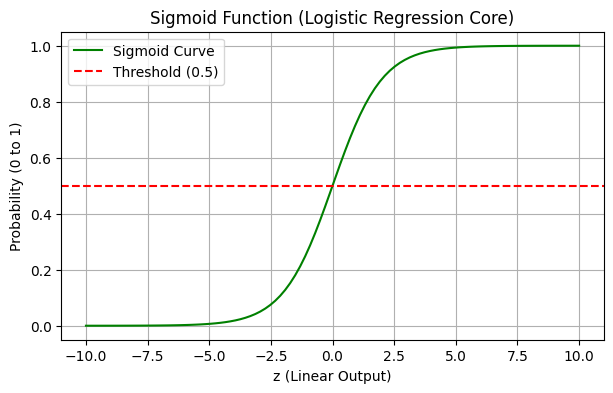

In [2]:
# ==========================================================
# 1. [시그모이드 함수 그래프 그리기] & [로지스틱 회귀 이해 기초]
# ==========================================================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)
plt.figure(figsize=(7, 4))
plt.plot(x, sigmoid(x), color='green', label='Sigmoid Curve')
plt.axhline(0.5, color='red', linestyle='--', label='Threshold (0.5)') # 분류의 기준점
plt.title("Sigmoid Function (Logistic Regression Core)")
plt.xlabel("z (Linear Output)")
plt.ylabel("Probability (0 to 1)")
plt.legend()
plt.grid(True)
plt.show()
# 로지스틱 회귀는 선형 회귀 결과값을 이 S자 곡선에 통과시켜 0~1 사이의 '확률'로 바꿉니다.

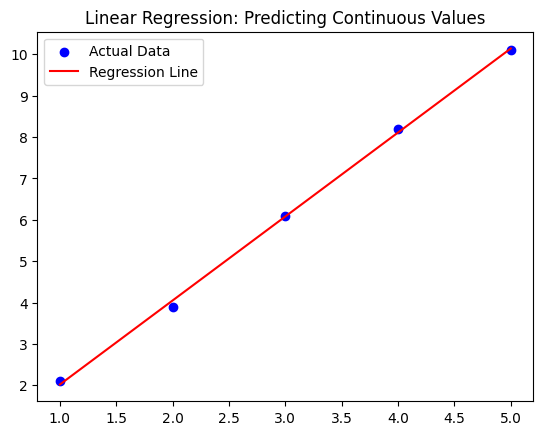

In [3]:
# ==========================================================
# 2. [선형 회귀 모델 이해하기]
# ==========================================================
from sklearn.linear_model import LinearRegression

# 간단한 데이터: 공부 시간(X)에 따른 예상 점수(y)
X_reg = np.array([[1], [2], [3], [4], [5]])
y_reg = np.array([2.1, 3.9, 6.1, 8.2, 10.1])

reg_model = LinearRegression()
reg_model.fit(X_reg, y_reg) # 모델 학습

plt.scatter(X_reg, y_reg, color='blue', label='Actual Data')
plt.plot(X_reg, reg_model.predict(X_reg), color='red', label='Regression Line') # 최적의 직선
plt.title("Linear Regression: Predicting Continuous Values")
plt.legend()
plt.show()

In [4]:
# ==========================================================
# 3. [지도 학습과 비지도 학습의 차이] & [다양한 분류 알고리즘 실습]
#    포함: 나이브 베이즈, 결정 트리, 로지스틱 회귀, k-NN
# ==========================================================
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# [지도 학습] 예시: 아이리스(붓꽃) 데이터셋 (꽃잎 정보를 보고 품종 정답(Label)을 맞춤)
iris = load_iris()
# 데이터를 학습용(80%)과 테스트용(20%)으로 분리
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

# 각 알고리즘별 모델 생성
models = {
    "Logistic Regression": LogisticRegression(max_iter=200), # [로지스틱 회귀]
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5), # [k-최근접 이웃(k-NN)]
    "Decision Tree": DecisionTreeClassifier(), # [결정 트리 알고리즘]
    "Naive Bayes": GaussianNB() # [나이브 베이즈 분류기]
}

print("--- [머신러닝 모델 평가 지표 학습 결과] ---\n")

for name, model in models.items():
    # 모델 학습 (지도 학습: 특징 데이터와 정답을 함께 전달)
    model.fit(X_train, y_train)

    # 예측 수행
    y_pred = model.predict(X_test)

    # [머신러닝 모델 평가 지표]
    acc = metrics.accuracy_score(y_test, y_pred) # 정확도
    report = metrics.classification_report(y_test, y_pred) # 정밀도, 재현율, F1-score 포함

    print(f"모델명: {name}")
    print(f"정확도(Accuracy): {acc:.4f}")
    print(f"상세 평가 지표:\n{report}")
    print("-" * 60)

--- [머신러닝 모델 평가 지표 학습 결과] ---

모델명: Logistic Regression
정확도(Accuracy): 1.0000
상세 평가 지표:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

------------------------------------------------------------
모델명: k-Nearest Neighbors
정확도(Accuracy): 1.0000
상세 평가 지표:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

--------------------------------

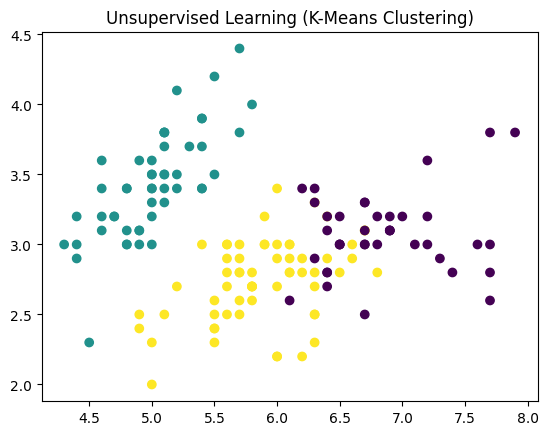

In [5]:
# ==========================================================
# 4. [비지도 학습 맛보기] (지도 학습과의 차이점 확인용)
# ==========================================================
from sklearn.cluster import KMeans

# 정답(y_test) 없이 데이터만 사용하여 스스로 그룹을 나눔
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(iris.data)

plt.scatter(iris.data[:, 0], iris.data[:, 1], c=clusters, cmap='viridis')
plt.title("Unsupervised Learning (K-Means Clustering)")
plt.show()